<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 15px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h1 style="color: white; font-family: 'Arial', sans-serif; margin: 0; font-size: 36px; text-align: center;">
        📊 Exercise project 1 – Linear regression
    </h1>
    <p style="color: #f0f0f0; text-align: center; font-size: 18px; margin-top: 10px;">
        ML Model: Car Price Dataset
    </p>
</div>

<img src="https://img.freepik.com/premium-photo/bmw-various-models_551707-84790.jpg?semt=ais_hybrid&w=740&q=80"
     width="800"
     style="border-radius: 20px;"
     alt="Data Cleaning">



<h4><b>Dataset name:</b></h4>
<a href="https://www.kaggle.com/datasets/aliiihussain/car-price-prediction">Car Price Prediction Dataset (2025)</a>

<h4><b>Data format:</b></h4>


Single csv-fie 

<h4><b>Data description, features and limitations</b></h4>

This dataset contains real car listings used to predict market prices. It is built for practicing regression models and data cleaning.


Key Features:

* Identity: Car ID, Brand, and Model.
* Age & Use: Manufacturing Year and total Mileage (km).
* Specs: Fuel Type (Petrol, Electric, etc.) and Transmission.
* Status: The car's physical Condition.
* Target: The final Market Price.


Limitations:

* Missing History: No info on accidents or past repairs.
* No Location: Prices change by city or country, but that isn't listed here.
* Market Changes: It doesn't account for current inflation or shifts in car trends.
* Small Details: Missing extra features like leather seats or tech upgrades that boost value.

<div style="background-color: #fff3cd; border: 2px solid #ffc107; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #856404; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #856404; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Don't skip ahead!
    </p>
</div>

<details open>
<summary>

## STEP 1 - Loading the data

</summary>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 60px; text-align: center; border-radius: 8px; margin: 20px 0;">
  <div style="display: inline-block; width: 40px; height: 40px; border: 4px solid rgba(255,255,255,0.3); border-top: 4px solid #fff; border-radius: 50%; animation: spin 1s linear infinite; margin-bottom: 20px;"></div>
  
  <h2 style="color: #fff; font-size: 36px; margin: 0;">Loading Data</h2>
</div>

</details>

<style>
@keyframes spin {
  0% { transform: rotate(0deg); }
  100% { transform: rotate(360deg); }
}
</style>

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [302]:
# Loading the required modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.pipeline import make_pipeline


In [303]:
# load the data
df = pd.read_csv("car_price_prediction_.csv")
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


---

<img src="https://library.ascd.org/m/526d848bf45addcf/webimage-shutterstock_424701814.jpg"
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

## 🔬 STEP 2: Let's Explore!

<h5><b>Code: Basic data checks, duplicates or missing values (NaN)?</b></h5>

In [304]:
# let's quickly see the first 5 rows of data
df.head(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [305]:
# printing total no.s of rows and columns of whole dataset
df.shape

(2500, 10)

In [306]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [307]:
# getting statistical summary of the dataframe
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


---

<img src="https://edure.in/wp-content/uploads/2024/10/1_aDiW2KddpHmTF3uAiibTCQ.png" 
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

<h3><b>Code: Data clean-up procedure</b></h3>

In [308]:
# checking the nan values in the dataset
df.isna().sum() 

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [309]:
# checking duplicates in the dataset 

duplicates = df[df.duplicated()]
duplicates

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model


In [310]:
# dropping car id and model column

df = df.drop(columns=['Car ID'], axis=1)
df = df.drop(columns=['Model'], axis=1)

In [311]:
# df = df[df["Condition"] == "New"]

<div style="border: 4px solid #fff; padding: 5px; background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); margin: 5px 0; text-align: left;">
  <h2 style="color: #fff; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>

The data has 2,500 rows and 10 columns. Lots of these are numbers, which makes training our X and y splits a lot easier.

We are getting rid of the car ID and model columns. The ID is just a tag and doesn't tell us anything about the price. 
The model has 28 types, and that's just too many extra variables for the data we have.

Luckily, there are no empty spots or null values. That is great because missing data usually messes up the machine learning model when it tries to learn.
</div>

---

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20240226130606/What-is-Data-Preparation.webp" 
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

**Case 1: Binary variables (only two options)**

In [312]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time

from sklearn.preprocessing import LabelEncoder
variables = ['Transmission']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

**Case 2: Ordinal variables (categories that have an order/rank -> can be compared)**

In [313]:
# variable 1: cut

cut_mapping = {"New": 3, "Used": 1, "Like New": 2}
df['Condition'] = df['Condition'].map(cut_mapping)

**Case 3: Nominal categories (categories that can't be compared numerically)**

In [314]:

# Nominal categories
# this makes multiple columns with the variable (Separate for yes/no)
# Not using year and milage 

from sklearn.preprocessing import OneHotEncoder
variables = [ "Brand", 'Fuel Type']

# using encoder

encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

<div style="border: 4px solid #fff; padding: 5px; background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); margin: 5px 0; text-align: left;">
  <h2 style="color: #fff; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>
For the first case, I changed the transmission column into a binary variable. Since it only had two options, using 0s and 1s works best.

In the second case, I gave the car conditions a score. I set "new" as 3, "like new" as 2, and "used" as 1.

Lastly in the third case, I fixed the categories for engine size, brand, and fuel type. I transformed those so the computer can actually read them as labels.
</div>

---

<img src="https://miro.medium.com/v2/resize:fit:1400/0*glGKhkPXa18w-4wx" 
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

## STEP 3: X/y and train/test -split

### Data preparation as X and Y

In [315]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Price", axis=1)

# our target variable is y
y = df['Price']

In [316]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Data is good to go (all numbers) => train model etc.

 <div style="background-color: #e7f3ff; border-left: 5px solid #2196F3; padding: 15px; margin: 20px 0; border-radius: 5px;">
    <h3 style="color: #1976D2; margin-top: 0;">🔑 Key Insight: Training the X and the y split</h3>
    <p style="color: #1565C0;">
        
        I have used the 30 70 split for this model
</div>

---

<img src="https://miro.medium.com/v2/resize:fit:1400/1*acmEFo8-JxQvg05frRrpCQ.jpeg" 
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

### STEP 4: Create and train the ML model

In [317]:
# create the model and train it with the data

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [318]:
# model = RandomForestRegressor(random_state=42).fit(X_train, y_train)
# model

 <div style="background-color: #e7f3ff; border-left: 5px solid #2196F3; padding: 15px; margin: 20px 0; border-radius: 5px;">
    <h3 style="color: #1976D2; margin-top: 0;">🔑 Key Insight: Random Forest Regression  </h3>
    <p style="color: #1565C0;">
        
    I have used Random Forest Regression to check if can we use it instead of linear Regression to make a workable ML model. 
</div>

In [319]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

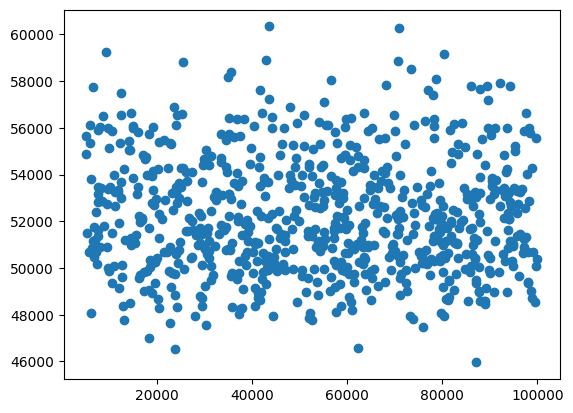

In [320]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences
plt.scatter(y_test, predictions)
plt.show()

<div style="border: 4px solid #fff; padding: 5px; background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); margin: 5px 0; text-align: left;">
  <h2 style="color: #fff; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>


    The scatter plot reveals poor model performance
  <i style='color:orange ; background-color:black;'> In an ideal model, points should follow a diagonal line indicating accurate predictions. 

</div>

---

### STEP 5: Error and performance metrics

<img src="https://images.squarespace-cdn.com/content/v1/5e51872712c0b73372f8fa1a/14b656b0-072d-436b-9746-712f87564b5a/Performance+Testing.png" 
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

In [321]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} $")


# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")


MAE:
23381.76 $

MSE:
737358457.21 $^2

RMSE:
27154.35 $

R-squared:
-0.02


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_12500/2665833334.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


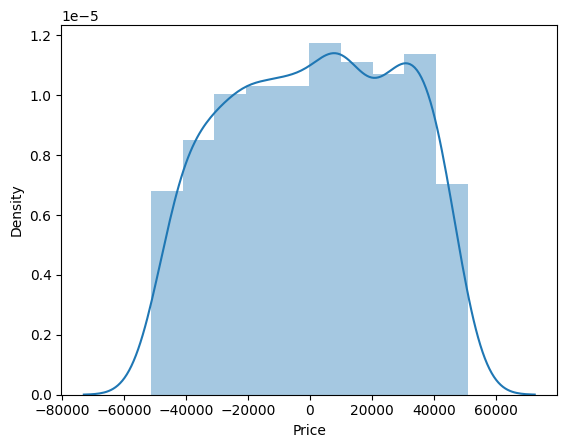

In [322]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far

sns.distplot((y_test - predictions))
plt.show()
plt.close()

In [323]:
X.columns

Index(['Year', 'Engine Size', 'Transmission', 'Mileage', 'Condition',
       'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda',
       'Brand_Mercedes', 'Brand_Tesla', 'Brand_Toyota', 'Fuel Type_Diesel',
       'Fuel Type_Electric', 'Fuel Type_Hybrid', 'Fuel Type_Petrol'],
      dtype='object')

<div style="border: 4px solid #fff; padding: 5px; background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); margin: 5px 0; text-align: left;">
  <h2 style="color: #fff; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>

  <i style='color:orange ; background-color:black;'> 
    R-squared: -0.01
    
    The R-squared is -0.01, which is pretty bad. Usually, this number stays between 0 and 1. Since it's negative, the model is actually worse than if we just guessed the average price for every car. It really isn't fitting the data at all.
  <i style='color:orange ; background-color:black;'> 
</div>

---

In [324]:
df

,Year,Engine Size,Transmission,Mileage,Condition,Price,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Diesel,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol
0,2016,2.3,1,114832,3,26613.92,0,0,0,0,0,1,0,0,0,0,1
1,2018,4.4,1,143190,1,14679.61,0,1,0,0,0,0,0,0,1,0,0
2,2013,4.5,1,181601,3,44402.61,1,0,0,0,0,0,0,0,1,0,0
3,2011,4.1,0,68682,3,86374.33,0,0,0,0,0,1,0,1,0,0,0
4,2009,2.6,1,223009,2,73577.10,0,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2020,2.4,0,22650,2,61384.10,1,0,0,0,0,0,0,0,0,0,1
2496,2001,5.7,1,77701,2,24710.35,1,0,0,0,0,0,0,0,0,1,0
2497,2021,1.1,1,272827,2,29902.45,0,0,1,0,0,0,0,0,0,1,0
2498,2002,4.5,1,229164,2,46085.67,1,0,0,0,0,0,0,1,0,0,0


## Using the model in practice

In [325]:
# Checking the columns for making the GUI
df.columns.tolist()

['Year',
 'Engine Size',
 'Transmission',
 'Mileage',
 'Condition',
 'Price',
 'Brand_Audi',
 'Brand_BMW',
 'Brand_Ford',
 'Brand_Honda',
 'Brand_Mercedes',
 'Brand_Tesla',
 'Brand_Toyota',
 'Fuel Type_Diesel',
 'Fuel Type_Electric',
 'Fuel Type_Hybrid',
 'Fuel Type_Petrol']

In [326]:
# usually in GUI application we save the model-object / variable into a file (by using joblib-module)
# and in the GUI application => we load the saved model from the file
# and use the model just like here below

# this variable could be connected to a user interface (textbox, slider etc.)

# map all the variables from the user
# into a Python dictionary
# the variable names have to match with the original dataset

tester_row = {

    'Year': '2010',
    'Engine Size' : '2.3',
    'Transmission' : '1',
    'Mileage' : '10000',
    'Condition' : '2',
    'Price' : '1',
    'Brand_Audi' : '0',
    'Brand_BMW' : '0',
    'Brand_Ford' : '0',
    'Brand_Honda' : '0',
    'Brand_Mercedes' : '0',
    'Brand_Tesla' : '0',
    'Brand_Toyota' : '1',
    'Fuel Type_Diesel' : '0',
    'Fuel Type_Electric' : '0',
    'Fuel Type_Hybrid' : '0',
    'Fuel Type_Petrol' : '1'

}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

In [327]:
# get the output/result from the model
# based on the user's given new data (above code cell)

result = model.predict(input_row)[0]

print()
print("Predicted car price for the new input:")
print(f"$ {round(float(result), 2)}")
print("----------------------------")


Predicted car price for the new input:
$ 48667.87
----------------------------


---

<img src="https://howtoapplyforgrants.com/wp-content/uploads/2023/09/STAKHOLDER-2.jpg" 
style="max-width: 300px; width: 100%; height: auto; border-radius: 20px; display: block;">

<div style="border: 4px double #4ecdc4; padding: 3px; background: #0f3460; margin: 20px 0;">
  <div style="border: 2px solid #4ecdc4; padding: 20px; background: #1a1a2e;">
    <h2 style="color: #4ecdc4; margin: 0; font-size: 2em;">🔍 CONCLUSION</h2>

  <i style='color:orange ; background-color:black;'>
    To sum it all up, this linear regression model just didn't work. 
    It’s not something we can use in the real world yet.</i>

  
    The R-squared was -0.01, which is a big red flag.
    It means the model couldn't even beat a basic guess of the average price. It failed to find any real patterns

    
    If we want to fix this, we have a few choices based on what we've learned:
    We could try to get better data.
  </div>
</div>